In [1]:
import pandas as pd
import csv
import ast

df = pd.read_csv(
    "processed_vaccine_tweets.csv",
    engine="python",
    on_bad_lines="skip",
    sep=",",
    quotechar='"',
    escapechar="\\"
)

print(df.shape)
print(df.columns)

(227317, 33)
Index(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet', 'account_age_days', 'clean_text', 'text_length',
       'word_count', 'hashtag_count', 'engagement', 'followers_log',
       'friends_log', 'verified_user', 'sentiment', 'exclamation_count',
       'question_count', 'hour', 'day_of_week', 'month', 'hashtag_list',
       'high_amplification'],
      dtype='object')


In [2]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# remove rows where date failed to parse
df = df[df['date'].notna()]

print("Date column cleaned")
print(df['date'].head())

Date column cleaned
0   2020-12-20 06:06:44
1   2020-12-13 16:27:13
2   2020-12-12 20:33:45
3   2020-12-12 20:23:59
4   2020-12-12 20:17:19
Name: date, dtype: datetime64[ns]


In [3]:
df['retweets'] = pd.to_numeric(df['retweets'], errors='coerce')
df['favorites'] = pd.to_numeric(df['favorites'], errors='coerce')

df = df[df['retweets'].notna() & df['favorites'].notna()]

df['engagement'] = df['retweets'] + df['favorites']

In [4]:
# Convert to numeric safely
df['retweets'] = pd.to_numeric(df['retweets'], errors='coerce').fillna(0)
df['favorites'] = pd.to_numeric(df['favorites'], errors='coerce').fillna(0)

# Combined metric (for comparison only)
df['engagement'] = df['retweets'] + df['favorites']

# Log transformations (reduce skew)
import numpy as np
df['log_retweets'] = np.log1p(df['retweets'])
df['log_favorites'] = np.log1p(df['favorites'])
df['log_engagement'] = np.log1p(df['engagement'])

# Quick sanity check
print("\nSummary stats:")
print(df[['retweets', 'favorites', 'engagement']].describe())


Summary stats:
            retweets      favorites     engagement
count  227281.000000  227281.000000  227281.000000
mean        2.494331      10.845935      13.340266
std        51.182650     199.927197     246.997872
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000
50%         0.000000       0.000000       1.000000
75%         1.000000       2.000000       3.000000
max     12294.000000   54017.000000   66311.000000


In [5]:
print(df[['retweets', 'favorites', 'engagement']].dtypes)
print(df[['retweets', 'favorites', 'engagement']].head())

retweets      float64
favorites     float64
engagement    float64
dtype: object
   retweets  favorites  engagement
0       0.0        0.0         0.0
1       1.0        1.0         2.0
2       0.0        0.0         0.0
3     446.0     2129.0      2575.0
4       0.0        0.0         0.0


In [6]:
# ==============================
# SECTION: Threshold Definition
# ==============================

# Engagement thresholds
eng_q90 = df['engagement'].quantile(0.90)
eng_q95 = df['engagement'].quantile(0.95)
eng_q99 = df['engagement'].quantile(0.99)

# Retweet threshold (important)
rt_q90 = df['retweets'].quantile(0.90)

# Favorite threshold
fav_q90 = df['favorites'].quantile(0.90)

# Create labels
df['high_eng_90'] = (df['engagement'] >= eng_q90).astype(int)
df['high_eng_95'] = (df['engagement'] >= eng_q95).astype(int)
df['high_rt_90'] = (df['retweets'] >= rt_q90).astype(int)
df['high_rt_95'] = (df['retweets'] >= rt_q90).astype(int)
df['high_fav_90'] = (df['favorites'] >= fav_q90).astype(int)
df['high_fav_95'] = (df['favorites'] >= fav_q90).astype(int)

# Print clearly
print("\nThresholds:")
print(f"Engagement 90%: {eng_q90}")
print(f"Retweets 90%: {rt_q90}")
print(f"Favorites 90%: {fav_q90}")

print("\nClass balance:")
print("Engagement:", df['high_eng_90'].value_counts(normalize=True))
print("Retweets:", df['high_rt_90'].value_counts(normalize=True))
print("Favorites:", df['high_fav_90'].value_counts(normalize=True))


Thresholds:
Engagement 90%: 12.0
Retweets 90%: 2.0
Favorites 90%: 9.0

Class balance:
Engagement: high_eng_90
0    0.899252
1    0.100748
Name: proportion, dtype: float64
Retweets: high_rt_90
0    0.864261
1    0.135739
Name: proportion, dtype: float64
Favorites: high_fav_90
0    0.893722
1    0.106278
Name: proportion, dtype: float64


In [7]:
# convert to datetime safely
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['user_created'] = pd.to_datetime(df['user_created'], errors='coerce')

# remove rows where conversion failed
df = df[df['date'].notna() & df['user_created'].notna()]

# reset index
df = df.reset_index(drop=True)

<Axes: title={'center': 'Tweet Activity Over Time'}, xlabel='date'>

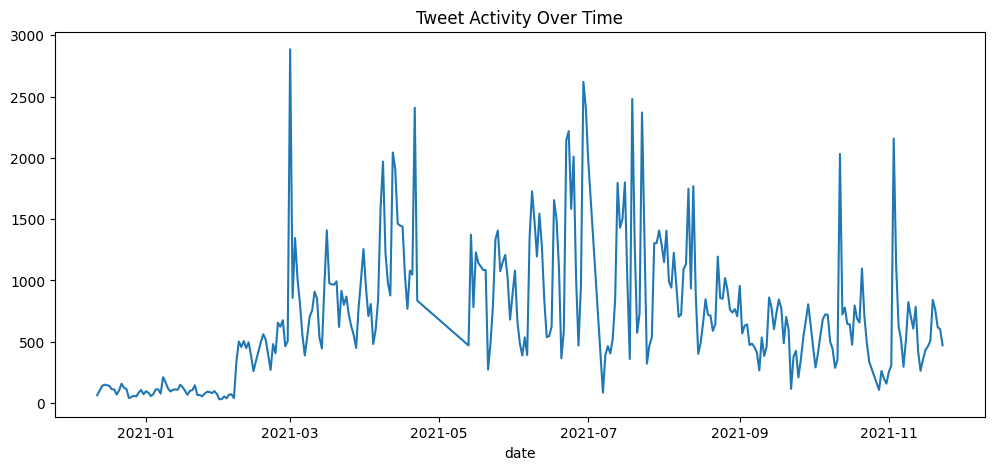

In [8]:
df['date'] = pd.to_datetime(df['date'])

tweets_per_day = df.groupby(df['date'].dt.date).size()

tweets_per_day.plot(figsize=(12,5), title="Tweet Activity Over Time")

<Axes: title={'center': 'Average Engagement Over Time'}, xlabel='date'>

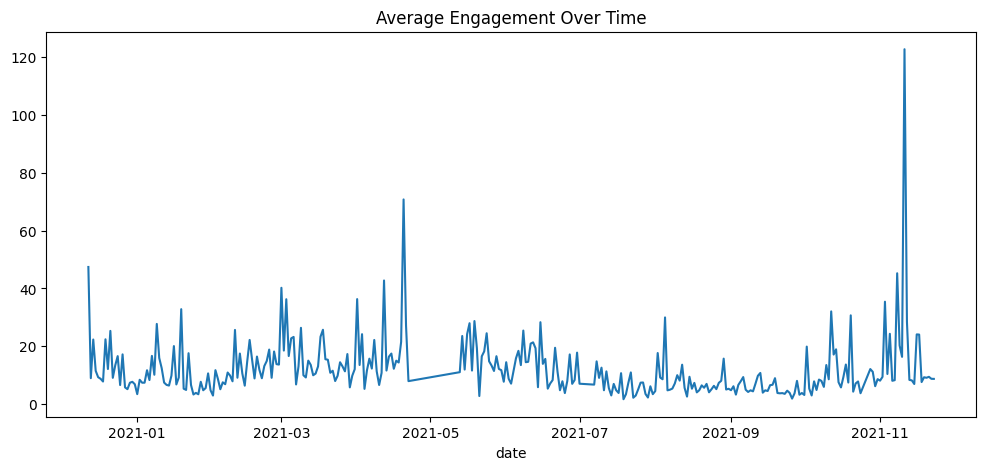

In [9]:
engagement_per_day = df.groupby(df['date'].dt.date)['engagement'].mean()

engagement_per_day.plot(figsize=(12,5), title="Average Engagement Over Time")

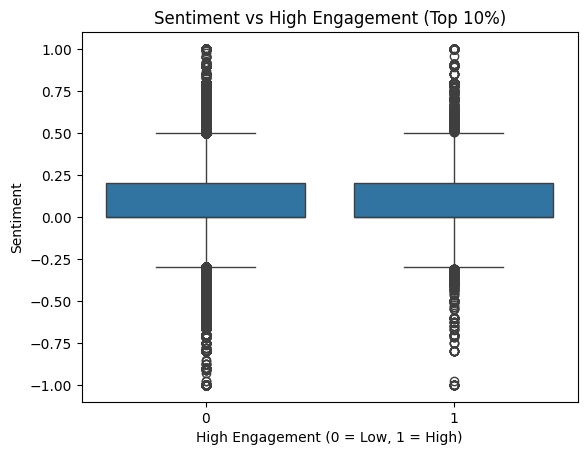

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='high_eng_90', y='sentiment', data=df)

plt.title("Sentiment vs High Engagement (Top 10%)")
plt.xlabel("High Engagement (0 = Low, 1 = High)")
plt.ylabel("Sentiment")
plt.show()

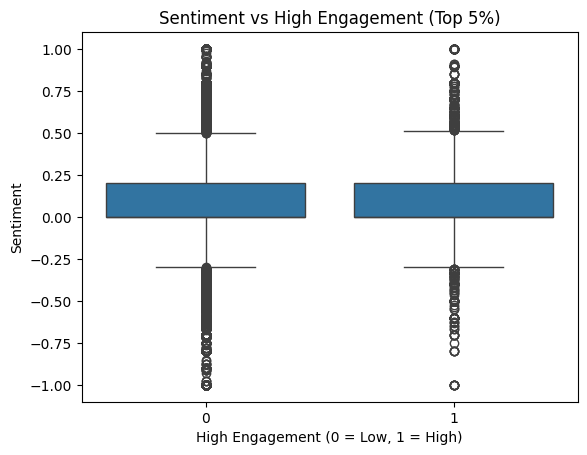

In [11]:
sns.boxplot(x='high_eng_95', y='sentiment', data=df)
plt.title("Sentiment vs High Engagement (Top 5%)")
plt.xlabel("High Engagement (0 = Low, 1 = High)")
plt.ylabel("Sentiment")
plt.show()

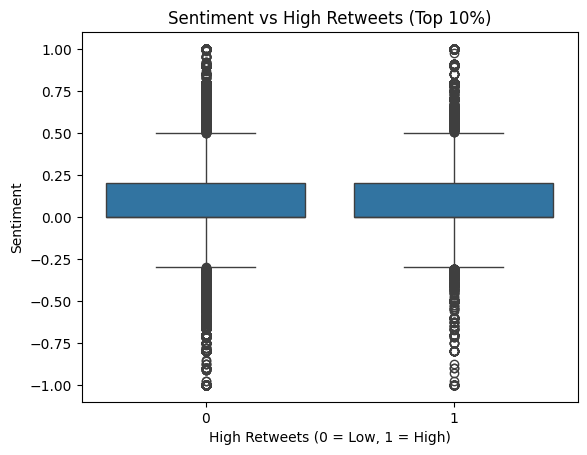

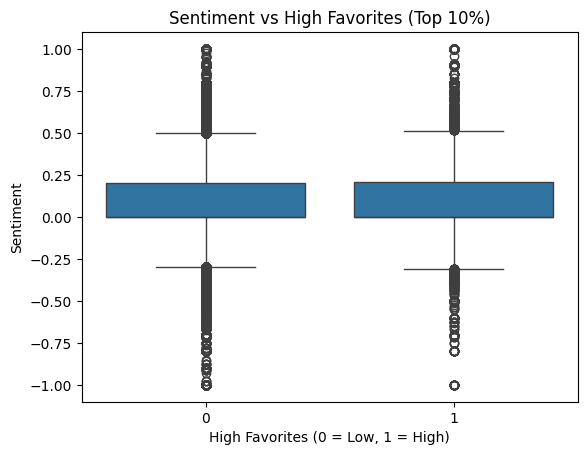

In [12]:
sns.boxplot(x='high_rt_90', y='sentiment', data=df)
plt.title("Sentiment vs High Retweets (Top 10%)")
plt.xlabel("High Retweets (0 = Low, 1 = High)")
plt.ylabel("Sentiment")
plt.show()

sns.boxplot(x='high_fav_90', y='sentiment', data=df)
plt.title("Sentiment vs High Favorites (Top 10%)")
plt.xlabel("High Favorites (0 = Low, 1 = High)")
plt.ylabel("Sentiment")
plt.show()

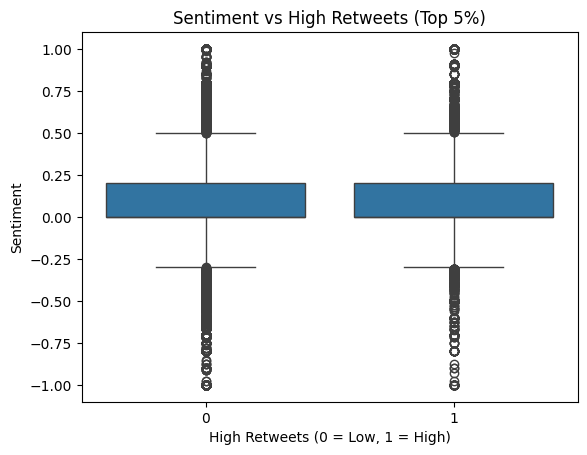

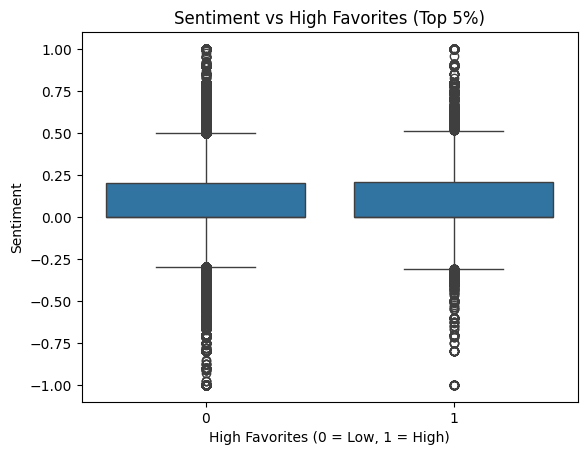

In [30]:
sns.boxplot(x='high_rt_95', y='sentiment', data=df)
plt.title("Sentiment vs High Retweets (Top 5%)")
plt.xlabel("High Retweets (0 = Low, 1 = High)")
plt.ylabel("Sentiment")
plt.show()

sns.boxplot(x='high_fav_95', y='sentiment', data=df)
plt.title("Sentiment vs High Favorites (Top 5%)")
plt.xlabel("High Favorites (0 = Low, 1 = High)")
plt.ylabel("Sentiment")
plt.show()

In [14]:
hashtags_df = df.explode('hashtag_list')
hashtags_df = hashtags_df[hashtags_df['hashtag_list'].notna()]
hashtags_df['hashtag_list'] = hashtags_df['hashtag_list'].astype(str).str.lower().str.strip()

top_hashtags = hashtags_df['hashtag_list'].value_counts().head(20)
print(top_hashtags)

hashtag_list
[]                                                                   48798
["['covaxin']"]                                                      22738
["['moderna']"]                                                      13139
["['covaxin',", "'bbmp']"]                                           11116
["['sputnikv']"]                                                      5816
["['sinovac']"]                                                       3123
["['sinopharm']"]                                                     2924
["['bbmp',", "'bengaluru',", "'covidvaccine',", "'covishield']"]      2922
["['urban',", "'bengaluru',", "'covidvaccine',", "'covishield']"]     2690
["['covid19']"]                                                       1913
["['pfizerbiontech']"]                                                1813
["['pfizer',", "'moderna']"]                                          1522
["['covaxin',", "'gurgaoncovaxin']"]                                  1166
["['oxfordas

In [15]:
hashtag_engagement = (
    hashtags_df.groupby('hashtag_list')['engagement']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

print(hashtag_engagement)

hashtag_list
["['vaccines',", "'covid19',", "'pfizer',", "'moderna',", "'vaccinessavelives',", "'vaccinated']"]                                 27317.000000
["['moderna',", "'covidvaccine',", "'thankyouscience',", "'imnotgonnacryincvs',", "'okimight',", "'dontjudge',", "'ithitsya']"]     8219.000000
["['teammolly',", "'themollyway',", "'covidvaccine',", "'booster',", "'thirdshot',", "'moderna',", "'stayhealthy']"]                3465.000000
["['pmmodi',", "'covaxin',", "'covishieldvaccine']"]                                                                                3345.000000
["['coronavirus',", "'oxfordvaccine']"]                                                                                             3228.000000
["['announce']"]                                                                                                                    2753.500000
["['covaxin',", "'navaraipur',", "'chhattisgarh']"]                                                                        

In [16]:
df['user_followers'] = pd.to_numeric(df['user_followers'], errors='coerce')
df['engagement'] = pd.to_numeric(df['engagement'], errors='coerce')

df = df[df['user_followers'].notna() & df['engagement'].notna()]

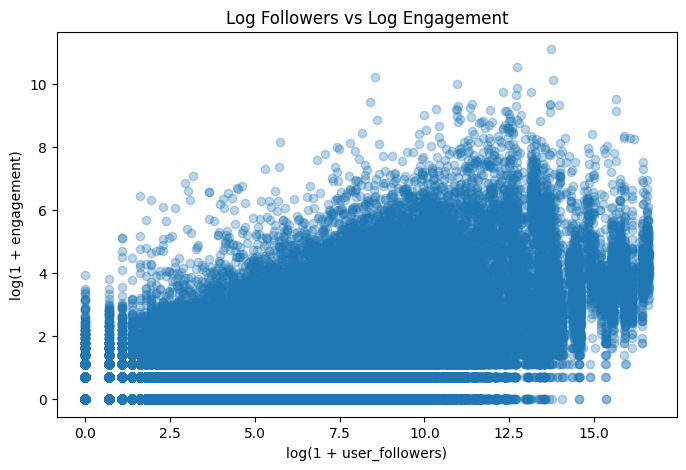

In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    np.log1p(df['user_followers']),
    np.log1p(df['engagement']),
    alpha=0.3
)

plt.xlabel("log(1 + user_followers)")
plt.ylabel("log(1 + engagement)")
plt.title("Log Followers vs Log Engagement")

plt.show()

In [18]:
df[['user_followers','engagement']].corr()

,user_followers,engagement
user_followers,1.000000,0.045555
engagement,0.045555,1.000000


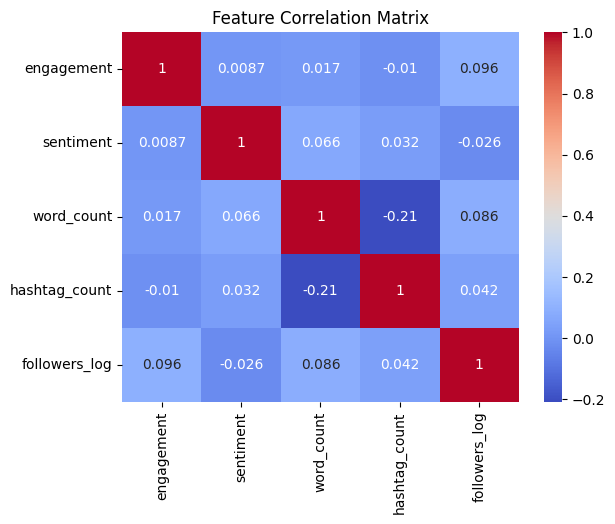

In [19]:
corr = df[[
    'engagement',
    'sentiment',
    'word_count',
    'hashtag_count',
    'followers_log'
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score

features = ['sentiment', 'word_count', 'hashtag_count', 'followers_log']
X = df[features]
y = df['high_eng_95']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_estimators=200
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[42514   669]
 [ 1637   637]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     43183
           1       0.49      0.28      0.36      2274

    accuracy                           0.95     45457
   macro avg       0.73      0.63      0.66     45457
weighted avg       0.94      0.95      0.94     45457

PR-AUC: 0.3792060996156441
ROC-AUC: 0.8617178571464212


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

features = ['sentiment', 'word_count', 'hashtag_count', 'followers_log']
X = df[features]
y = df['high_eng_95']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))

coef_df = pd.DataFrame({
    'feature': features,
    'coef': log_model.coef_[0]
}).sort_values('coef', ascending=False)

print(coef_df)

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     43183
           1       0.21      0.80      0.33      2274

    accuracy                           0.84     45457
   macro avg       0.60      0.82      0.62     45457
weighted avg       0.95      0.84      0.88     45457

         feature      coef
3  followers_log  0.595059
0      sentiment  0.531497
1     word_count  0.034765
2  hashtag_count -0.088939


In [21]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

followers_log    0.749822
sentiment        0.103323
word_count       0.099613
hashtag_count    0.047242
dtype: float64


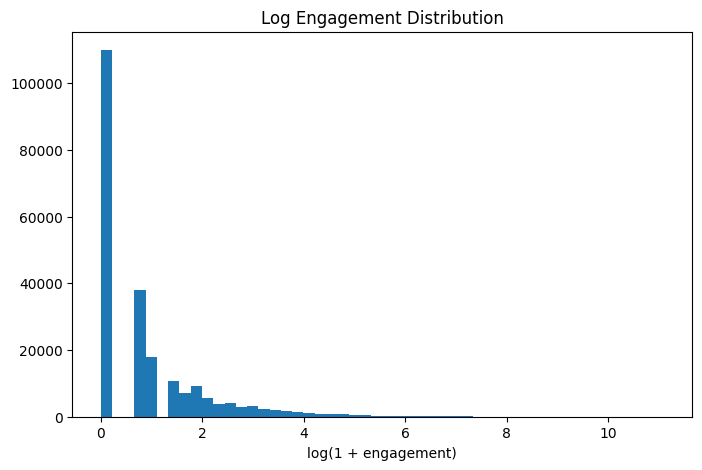

In [22]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['engagement']), bins=50)
plt.title("Log Engagement Distribution")
plt.xlabel("log(1 + engagement)")
plt.show()

In [23]:
import ast

def normalize_hashtag_list(x):
    # already a list
    if isinstance(x, list):
        tags = x
    # missing value
    elif pd.isna(x):
        return []
    # stringified list
    else:
        try:
            tags = ast.literal_eval(x)
        except:
            return []

    if not isinstance(tags, list):
        return []

    clean_tags = []
    for tag in tags:
        tag = str(tag).lower().strip()
        tag = tag.replace("[", "").replace("]", "").replace("'", "").replace('"', "").replace(",", "")
        if tag != "" and tag != "nan":
            clean_tags.append(tag)

    return clean_tags

df['hashtag_list_clean'] = df['hashtag_list'].apply(normalize_hashtag_list)

In [24]:
hashtags_df = df.explode('hashtag_list_clean')
hashtags_df = hashtags_df[hashtags_df['hashtag_list_clean'].notna()]
hashtags_df = hashtags_df[hashtags_df['hashtag_list_clean'] != ""]
hashtags_df = hashtags_df[hashtags_df['hashtag_list_clean'] != "nan"]

top_hashtags = hashtags_df['hashtag_list_clean'].value_counts().head(20)
print(top_hashtags)

hashtag_list_clean
covaxin           58657
moderna           44059
covid19           19323
sputnikv          14497
bbmp              14184
vaccine           13295
covidvaccine      12864
pfizer            12218
covishield        11432
sinovac           10377
sinopharm          8301
bengaluru          7025
pfizerbiontech     6548
covid              4775
astrazeneca        3925
vaccinated         3898
vaccines           3391
coronavirus        2777
urban              2769
covid19vaccine     2751
Name: count, dtype: int64


In [27]:
tag_counts = hashtags_df['hashtag_list_clean'].value_counts()

valid_tags = tag_counts[tag_counts >= 100].index  # choose 50 or 100
filtered_tags = hashtags_df[hashtags_df['hashtag_list_clean'].isin(valid_tags)]

hashtag_engagement = (
    filtered_tags.groupby('hashtag_list_clean')['engagement']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

print(hashtag_engagement)

hashtag_list_clean
argentina             140.706977
serbia                110.198276
vaccinessavelives      95.172840
aatmanirbharbharat     68.100917
oxfordvaccine          44.500000
sputnikv               43.826171
vaccineforall          34.260870
mexico                 33.788991
breaking               32.781449
cipla                  31.516854
chile                  30.411215
indiafightscorona      30.039634
philippines            28.613546
nepal                  28.324074
pmmodi                 27.889796
vaccinationdrive       26.188366
hungary                24.265432
aiims                  21.606987
covax                  21.543897
dollyparton            21.275000
Name: engagement, dtype: float64


In [28]:
corr2 = df[['retweets', 'favorites', 'sentiment', 'word_count', 'hashtag_count', 'followers_log']].corr()
print(corr2)

               retweets  favorites  sentiment  word_count  hashtag_count  \
retweets       1.000000   0.899920   0.006282    0.019812      -0.008469   
favorites      0.899920   1.000000   0.009087    0.015986      -0.010291   
sentiment      0.006282   0.009087   1.000000    0.066134       0.032088   
word_count     0.019812   0.015986   0.066134    1.000000      -0.207889   
hashtag_count -0.008469  -0.010291   0.032088   -0.207889       1.000000   
followers_log  0.083626   0.096696  -0.026074    0.085790       0.041794   

               followers_log  
retweets            0.083626  
favorites           0.096696  
sentiment          -0.026074  
word_count          0.085790  
hashtag_count       0.041794  
followers_log       1.000000  


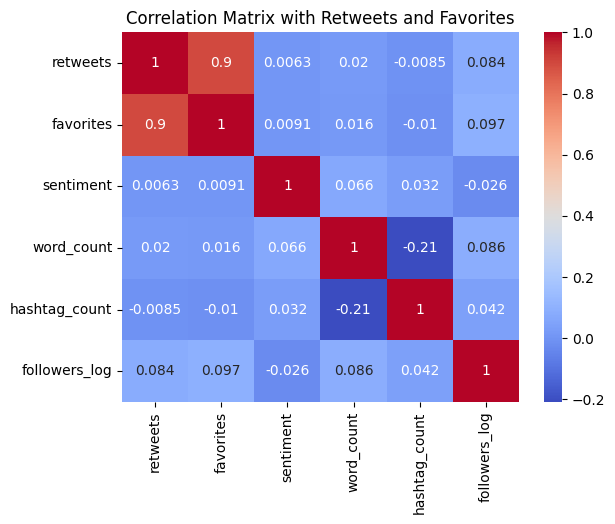

In [29]:
sns.heatmap(corr2, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix with Retweets and Favorites")
plt.show()